### Build a Basic ChatBot with LangGraph(Graph API)

In [1]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages

In [2]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages:Annotated[list,add_messages]

In [9]:
import os
from pathlib import Path
from langchain_groq import ChatGroq

# 1. Read the line we just confirmed is there
env_file_path = Path.cwd().parent / ".env"
with open(env_file_path, "r", encoding="utf-8") as f:
    line = f.read().splitlines()[0]

# 2. Extract the key directly from the text split
secret_key = line.split("=", 1)[1].strip()

# 3. Explicitly inject it into os.environ for LangGraph nodes to see
os.environ["GROQ_API_KEY"] = secret_key

# 4. Pass it directly to ChatGroq to guarantee it binds right now
llm = ChatGroq(
    model="llama3-8b-8192",
    groq_api_key=secret_key
)

print("✅ Model successfully initialized with the updated key!")

✅ Model successfully initialized with the updated key!


In [10]:

from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm=ChatGroq(model="llama3-8b-8192")

In [11]:
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.10'}}, output_version=None, profile={'name': 'Llama 3 8B', 'status': 'deprecated', 'release_date': '2024-04-18', 'last_updated': '2024-04-18', 'open_weights': True, 'max_input_tokens': 8192, 'max_output_tokens': 8192, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000013BFD7CE5D0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000013BFD7CEFD0>, model_name='llama3-8b-8192', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [13]:

## Node Functionality
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [14]:

graph_builder=StateGraph(State)

## Adding node
graph_builder.add_node("llmchatbot",chatbot)
## Adding Edges
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

## compile the graph
graph=graph_builder.compile()

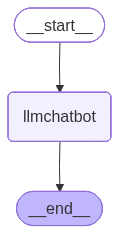

In [15]:

## Visualize the graph
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [17]:
import os
from langchain_groq import ChatGroq

# Re-initialize using a supported, active model
llm = ChatGroq(
    model="llama-3.1-8b-instant",  # Updated to a valid active model ID
    groq_api_key=os.environ["GROQ_API_KEY"]
)

print("✅ Model updated to an active version successfully!")

✅ Model updated to an active version successfully!


In [18]:
response = graph.invoke({"messages": "Hi"})
print(response)

{'messages': [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='da8d9902-51a1-4bdc-88f2-457522df93c1'), AIMessage(content='How can I help you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 8, 'prompt_tokens': 36, 'total_tokens': 44, 'completion_time': 0.009403196, 'completion_tokens_details': None, 'prompt_time': 0.001611995, 'prompt_tokens_details': None, 'queue_time': 0.046995564, 'total_time': 0.011015191}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ee9d4-a274-7af0-8b6f-17b3b96683df-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 8, 'total_tokens': 44})]}


In [19]:

response["messages"][-1].content

'How can I help you today?'

In [20]:
for event in graph.stream({"messages":"Hi How are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

I'm doing well, thank you for asking. I'm a large language model, so I don't have feelings in the same way that humans do, but I'm here to help you with any questions or tasks you have. How can I assist you today?


### Chatbot with Tool

In [23]:
import os
from pathlib import Path
from langchain_tavily import TavilySearch

# 1. Read your .env file cleanly
env_file_path = Path.cwd().parent / ".env"

tavily_key = None
with open(env_file_path, "r", encoding="utf-8") as f:
    for line in f:
        if line.strip().startswith("TAVILY_API_KEY"):
            tavily_key = line.split("=", 1)[1].strip().strip("'\"")
            break

# 2. Inject it into os.environ and initialize the tool
if tavily_key:
    os.environ["TAVILY_API_KEY"] = tavily_key
    
    # Initialize the tool by passing the key explicitly
    tool = TavilySearch(max_results=2, tavily_api_key=tavily_key)
    print("🎉 Success! Tavily search tool initialized completely.")
    
    # 3. Test it out!
    print("\nTesting tool invocation:")
    print(tool.invoke("What is langgraph"))
else:
    print("❌ Could not find a line starting with 'TAVILY_API_KEY' in your .env file.")
    print("Please double check that you added it and saved the file.")

🎉 Success! Tavily search tool initialized completely.

Testing tool invocation:
{'query': 'What is langgraph', 'follow_up_questions': None, 'answer': None, 'images': [], 'results': [{'url': 'https://www.geeksforgeeks.org/machine-learning/what-is-langgraph', 'title': 'What is LangGraph - GeeksforGeeks', 'content': "LangGraph is an open-source framework from LangChain designed to build and manage AI agent workflows using graph-based structures. It allows developers to define workflows as nodes and edges, making complex agent interactions more structured, scalable and easier to control. LangChain uses a straightforward step-by-step pipeline where each task follows a fixed sequence from input to output while LangGraph allows flexible workflows with branching and parallel steps, making it better suited for complex, decision-based applications. ## Workflow of LangGraph. The diagram below shows how LangGraph structures its agent-based workflow using distinct tools and stages. Here's a step by

In [24]:

## Custom function
def multiply(a:int,b:int)->int:
    """Multiply a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """
    return a*b

In [26]:
tools = [tool,multiply]

In [27]:
llm_with_tool=llm.bind_tools(tools)

In [28]:
llm_with_tool


_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.10'}}, output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000013BFD95AFD0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000013BFD95B950>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engin